# Case Intern Batch 1 - Edu

In this case, we will conduct Exploratory Data Analysis on a dataset, with the aim of uncovering insights and seeking valuable information within the presented data.

Code References if necessary, DO NOT PURELY IMITATE OR COPY-PASTE!!, consequences of plagiarism = 0

1. Detailed EDA : https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python
2. EDA: https://www.analyticsvidhya.com/blog/2020/08/exploratory-data-analysiseda-from-scratch-in-python/

### Dataset Introduction

Using Breast_cancer_data.csv dataset, you will find these attributes, that defined as:

- diagnosis: The diagnosis of breast tissues (1 = malignant, 0 = benign) where malignant denotes that the disease is harmful
- mean_radius: mean of distances from center to points on the perimeter
- mean_texture: standard deviation of gray-scale values
- mean_perimeter: mean size of the core tumor
- mean_area: mean area of the core tumor
- mean_smoothness: mean of local variation in radius lengths

## Import Libraries

In [15]:
#Write all neccesary libraries here
#Every library imported outside of this code block will reduce your final score 2 points each
#Don't forget to rerun this cell code if you import new library
# Manipulasi
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# ANOVA
from scipy.stats import f_oneway

#Add neccesary libraries here
import os
import warnings
warnings.filterwarnings("ignore")

## I. Data Exploration (20%)

In [16]:
#Read Breast_cancer_data.csv and store it into a dataframe named df.
df = pd.read_csv('Breast_cancer_data.csv')

In [17]:
#print first 5 data row from df using head()
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [18]:
#Make a general conclusion of the dataset
#Clue : use info() to gain insight

print("This datasets contains {} rows and column {} " .format(df.shape[0], df.shape[1]))

df.info()

This datasets contains 569 rows and column 6 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [21]:
#Check duplicate data and missing value in the dataset
#Check for Missing Value
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [22]:
#Check for Duplicate Data
df.duplicated().sum()

0

In [8]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [9]:
df["mean_smoothness"].value_counts()

mean_smoothness
0.10070    5
0.11500    4
0.10540    4
0.10750    4
0.10630    3
          ..
0.08876    1
0.09965    1
0.13230    1
0.08968    1
0.05263    1
Name: count, Length: 474, dtype: int64

Malignant == 1
Benign == 0

### Give a conclusion for what have you done on Data Exploration briefly!

## Answer

From the exploration above we can conclude that the data is relatively clean and there's no missing value or duplicate data. We can see the result of the exploration by the statistics below

### Data Exploration

**Read data** = The dataset containes 6 features which is "mean_radius", "mean_texture", "mean_perimeter", "mean_area", "mean_smoothness" dan "diagnosis"(seperti yang sudah di tulis diatas)

**Missing Value** = There's no missing value in this dataset

**Duplikasi Data** = There's no duplicate data in this dataset

**Data Type** = All of the data type is float64 except diagnosis is int64

### Describe Data

**mean_radius** = The mean of the mean_radius is 14.127292, the median is 13.37, the standard deviation is 3.524, the minimum is 6.981, the maximum is 28.11, the 25% is 11.7, the 50% is 13.37, the 75% is 15.78

**mean_texture** = The mean of the mean_texture is 19.289649, the median is 18.84, the standard deviation is 4.301, the minimum is 9.71, the maximum is 39.28, the 25% is 16.17, the 50% is 18.84, the 75% is 21.8

**mean_perimeter** = The mean of the mean_perimeter is 91.969033, the median is 86.24, the standard deviation is 24.299, the minimum is 43.79, the maximum is 188.5, the 25% is 75.17, the 50% is 86.24, the 75% is 104.1

**mean_area** = The mean of the mean_area is 654.889104, the median is 551.1, the standard deviation is 351.914, the minimum is 143.5, the maximum is 2501.0, the 25% is 420.3, the 50% is 551.1, the 75% is 782.7

**mean_smoothness** = The mean of the mean_smoothness is 0.09636, the median is 0.09587, the standard deviation is 0.014, the minimum is 0.05263, the maximum is 0.1634, the 25% is 0.08637, the 50% is 0.09587, the 75% is 0.1053

**diagnosis** = The mean of the diagnosis is 0.627417, the median is 0.626, the standard deviation is 0.096, the minimum is 0.36, the maximum is 1.0, the 25% is 0.57, the 50% is 0.626, the 75% is 0.693

## II. Exploratory Data Analysis (60%)

Make sure that your plot shows the expected output and contains title, xlabel,ylabel, and all neccesary attributes to create a good explanatory plot

Untuk menekankan proporsi variabel-variabel terhadap diagnosis, saya menggunakan visualisasi bar plot dan saya juga memberikan analisis menyeluruh tentang bagaimana **"mean_texture", "mean_smoothness", "mean_radius", "mean_area" dan "mean_perimeter"** mempengaruhi diagnosis. Dengan analisis ini dapat memberikan wawasan yang lebih mendalam tentang kontribusi tiap variabel terhadap diagnosis serta pemahaman yang lebih tentang perbedaan dan pengaruh masing-masing variabel terhadap hasil diagnosis. Selain itu, untuk memahami peran pentingnya, saya akan analisis mendalam tentang dampak observasi masing-masing variable terhadap diagnosis

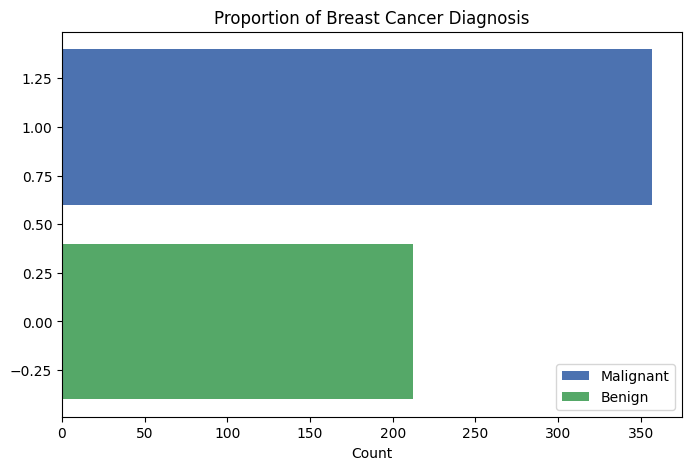

In [23]:
jumlah_diagnosa = df['diagnosis'].value_counts()
customcolors = ['#4C72B0', '#55A868']


plt.figure(figsize=(8,5))
bars_plot_untuk_legend = plt.barh(jumlah_diagnosa.index, jumlah_diagnosa.values, color=customcolors)
plt.xlabel('Count')
plt.title('Proportion of Breast Cancer Diagnosis')
plt.legend(bars_plot_untuk_legend, ["Malignant", "Benign"], loc = "lower right")
plt.show()


From the plot above we can see that most of the cases are malignant with more than 250 cases and the rest are benign with less than 250 cases. This shows that the data is not balanced but it's not too imbalanced either. So we can continue with the analysis

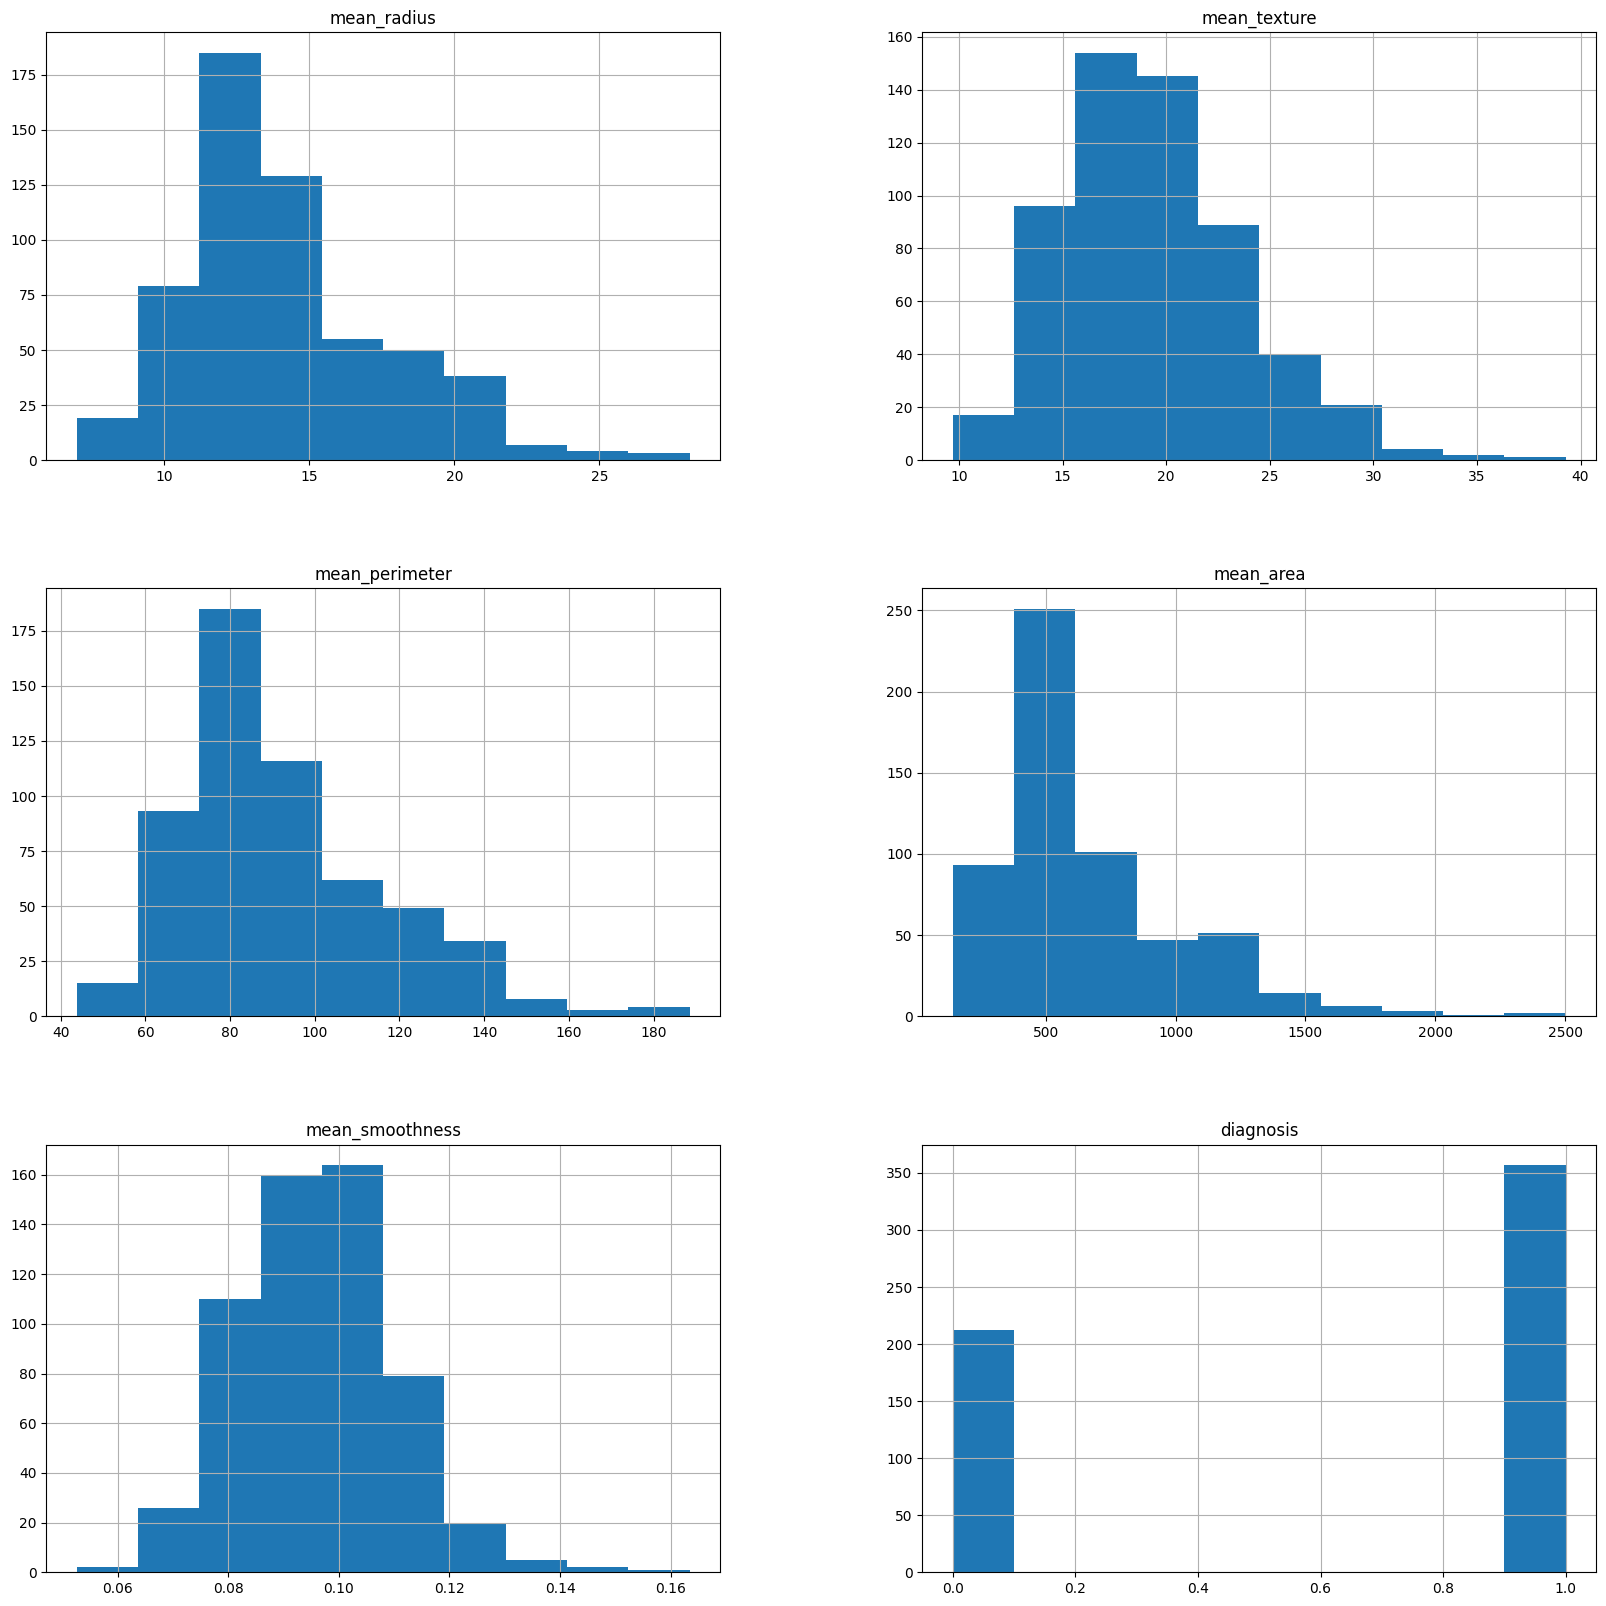

In [24]:
## DAta Visulaization

#Visualize the distribution of the data using histogram

df.hist(figsize=(20,20))
plt.show()

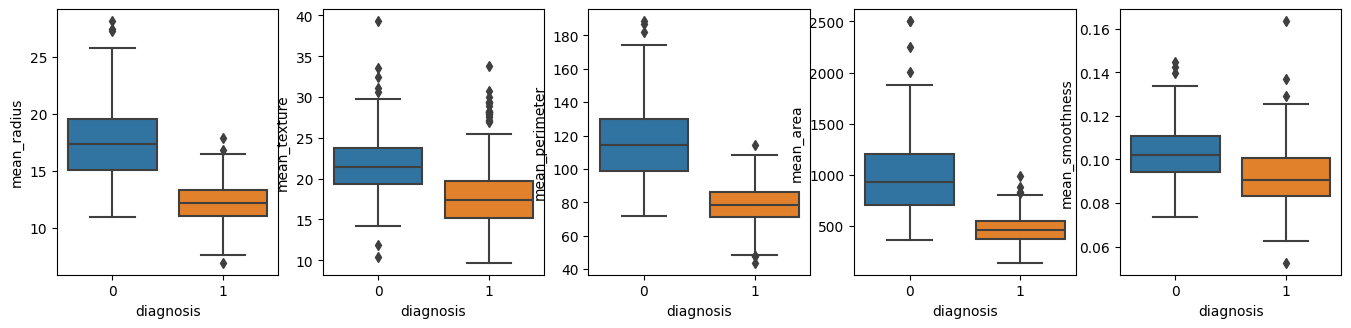

In [32]:
# Visualize the distribution of the data using boxplot for each column except for the diagnosis column

plt.figure(figsize=(20,20))
for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(5,6,i)
    sns.boxplot(x='diagnosis', y=column, data=df)

### Insight

#### Histogram

From the histogram and boxplot above we can see that except mean_smoothness all of the data is right skewed. This means that the data is not normally distributed. This is important to note because some machine learning algorithm requires the data to be normally distributed. So we need to do some transformation to the data before we can use it for machine learning algorithm.

#### Boxplot

From the boxplot above we can see that there are some outliers in the data. There's many outliers especiallyy in the mean_texture data. This is important to note because some machine learning algorithm is sensitive to outliers. So we need to do some transformation to the data before we can use it for machine learning algorithm.

### Conclusion

From the plotting and analysis above we can conclude that the data need some transformation before we can use it for machine learning algorithm. We need to do some transformation to the data because the data is not normally distributed and there's many outliers in the data. This is important to note because some machine learning algorithm requires the data to be normally distributed and some machine learning algorithm is sensitive to outliers.

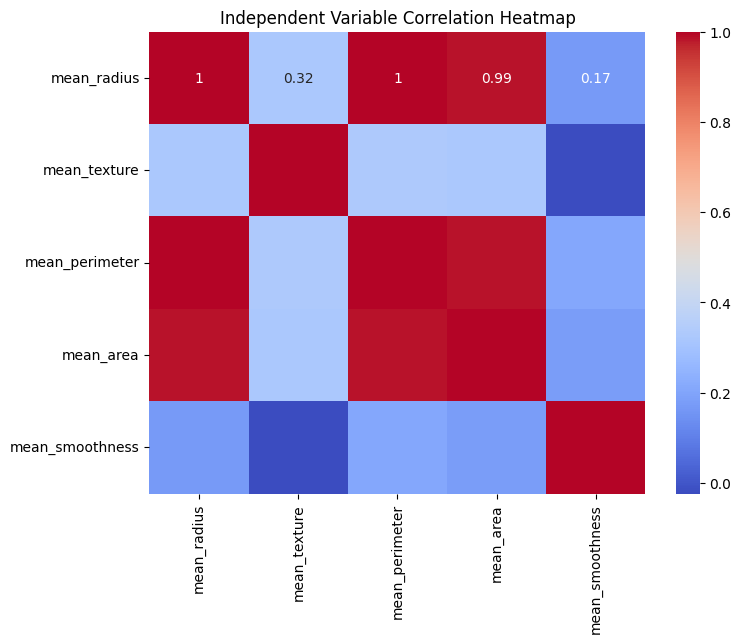

In [43]:
#2. Make correlation heatmap for the independent variables
#Write your code here

df_indpendent = df.drop(columns = ['diagnosis'])

df_indpendent.head()

correlation_matrix = df_indpendent.corr()

plt.figure(figsize = (8,6))
sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm")
plt.title("Independent Variable Correlation Heatmap")
plt.show()

The relationship between the features is depicted in the correlation heatmap above. The mean perimeter, mean radius, and mean area can be inferred to have a strong positive association with one another.

In [33]:
#3. THEORY(ANSWER IN MARKDOWN PROVIDED[ANSWER HERE FOR NUMBER 3])
#Using mean_radius, mean_area, and mean_perimeter will be a redundant attribute in a predicitive model
#Explain why this might be the case ? Refer to the correlation heatmap you create in number 2!!!
#You can add more graphs and statistical methods to support your explanation(Bonus Point Rewarded)


# Answer :
#


#Add plot here(Optional)



Kita menggunakan pair plot untuk mengetahui hubungan antara "mean_radius", "mean_area" dan "mean_perimeter. Saya akan mengamati variable yang mempuyai korelasi linear yang kuat di antara variable yang lain.


Jenis tumor "Benign" (0) cenderung memiliki nilai yang lebih rendah untuk variabel "mean_perimeter", "mean_radius", "mean_area", "mean_texture", dan "mean_smoothness", menurut pasangan plot yang ditampilkan. Sebaliknya, tumor jenis "Malignant" (1) cenderung memiliki nilai yang lebih tinggi untuk atribut-atribut ini, seperti yang ditunjukkan oleh penelitian yang menunjukkan perbedaan visual yang cukup konsisten antara kedua jenis tumor dalam hal atribut-atribut ini. Ada kemungkinan bahwa nilai-nilai ini memiliki peran dalam membedakan jenis tumor, karena nilai yang lebih tinggi pada variabel-variabel tersebut cenderung dikaitkan dengan jenis tumor yang lebih ganas (Malignant

It's redundant because each variable each varible have perfect correlaton with each other or in other terms perfect colinerity. This could induce multicolinearity, which makes it difficult to fetermine the effect of each variable

In [44]:
#4. Perform an ANOVA test on one of the independent variable for people with and without breast cancer
#You can add graphs to aid your explanation
#Don't forget to write your analysis on the result

#Write your code here
# do anova test for all independent variables
from scipy.stats import f_oneway

for column in df.columns[:-1]:
    benign = df[df['diagnosis'] == 0][column]
    malignant = df[df['diagnosis'] == 1][column]
    statistic, pvalue = f_oneway(benign, malignant)
    print(f'ANOVA test for {column}')
    print(f'p-value: {pvalue}')
    if pvalue < 0.05:
        print('reject null hypothesis')
    else:
        print('accept null hypothesis')
    print()

ANOVA test for mean_radius
p-value: 8.465940572263821e-96
reject null hypothesis

ANOVA test for mean_texture
p-value: 4.0586360478986136e-25
reject null hypothesis

ANOVA test for mean_perimeter
p-value: 8.436251036173951e-101
reject null hypothesis

ANOVA test for mean_area
p-value: 4.7345643103077244e-88
reject null hypothesis

ANOVA test for mean_smoothness
p-value: 1.051850359203376e-18
reject null hypothesis



Because the p-value is lower than 0.05 in all of the independent variables, we can conclude that all of the independent variables have a significant effect on the dependent variable.

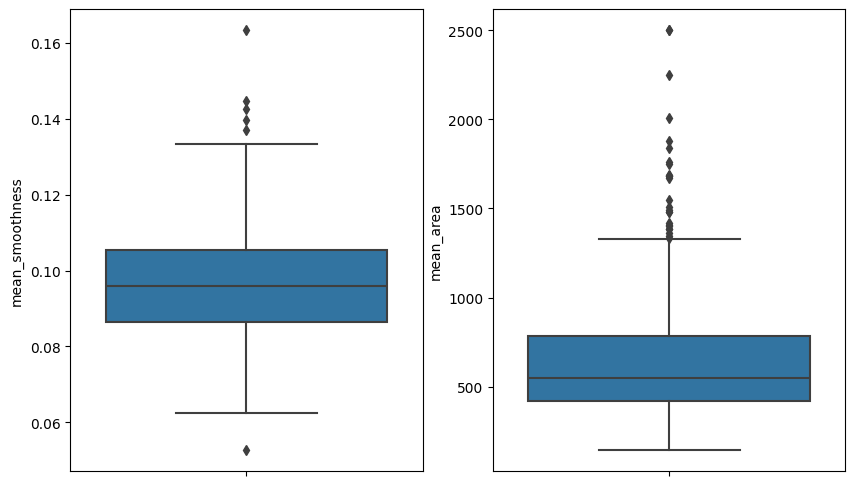

Outliers for mean_smoothness
3      0.14250
105    0.13980
122    0.14470
504    0.16340
520    0.13710
568    0.05263
Name: mean_smoothness, dtype: float64

Outliers for mean_area
23     1404.0
82     1878.0
108    1509.0
122    1761.0
164    1686.0
180    2250.0
202    1685.0
212    2499.0
236    1670.0
250    1364.0
265    1419.0
272    1491.0
339    1747.0
352    2010.0
368    1546.0
369    1482.0
372    1386.0
373    1335.0
393    1407.0
449    1384.0
461    2501.0
503    1682.0
521    1841.0
563    1347.0
564    1479.0
Name: mean_area, dtype: float64



In [14]:
#5. Perform Outlier Detection using boxplot for mean_smoothness and mean_area columns
#Show the total of each columns outliers and their data value

#Write your code here
# boxplot for mean_smoothness and mean_area
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['mean_smoothness'])
plt.subplot(1, 2, 2)
sns.boxplot(y=df['mean_area'])
plt.show()

# outliers for mean_smoothness
Q1 = df['mean_smoothness'].quantile(0.25)
Q3 = df['mean_smoothness'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print('Outliers for mean_smoothness')
print(df[(df['mean_smoothness'] < lower_bound) | (df['mean_smoothness'] > upper_bound)]['mean_smoothness'])
print()

# outliers for mean_area
Q1 = df['mean_area'].quantile(0.25)
Q3 = df['mean_area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print('Outliers for mean_area')
print(df[(df['mean_area'] < lower_bound) | (df['mean_area'] > upper_bound)]['mean_area'])
print()


## III. Video Explanation(10%)

Create an explanation video only on EDA Part (Part II), maximum time of the video is 5 minutes, explain all your plot and what insight that you get clearly and briefly.

Make sure your video link could be accessed and viewed, else your point will not counted

Copy your Link Here(OneDrive/Youtube) : https://binusianorg-my.sharepoint.com/personal/wilbert_chandra001_binus_ac_id/_layouts/15/guestaccess.aspx?share=EbCRtNA5vVZPub0oFFeZUgUBITKXDvQjUfYZ0LF7CPb3kg&e=dRZW4h

## IV. Bonus Score (10%)

Answer the question thoroughly and provide all references you used from TRUSTED SOURCE(Like Analythicsvidhya / w3schools / ibm /etc. ) OR any Publications/Journal, that helped you to answer this question

#### Question
#### Is Exploratory Data Analysis is important for data scientist? What is the main purpose of doing Exploratory Data Analysis?

Yes, Exploratory Data Analysis (EDA) is indeed very important for data scientists¹⁴. The main purpose of EDA is to help look at data before making any assumptions¹. It can help identify obvious errors, as well as better understand patterns within the data, detect outliers or anomalous events, find interesting relations among the variables¹. 

Data scientists can use exploratory analysis to ensure the results they produce are valid and applicable to any desired business outcomes and goals¹. EDA also helps stakeholders by confirming they are asking the right questions¹. EDA can help answer questions about standard deviations, categorical variables, and confidence intervals¹. Once EDA is complete and insights are drawn, its features can then be used for more sophisticated data analysis or modeling, including machine learning¹.

In general, EDA enables data scientists to make well-informed decisions, develop hypotheses, and establish a robust foundation for a comprehensive analysis⁴. This method enhances the overall understanding of the data and facilitates the data-driven decision-making process.

* (1) What is Exploratory Data Analysis? | IBM. https://www.ibm.com/topics/exploratory-data-analysis.
* (2) Maitra, M. (2023, September 12). Importance and impact of exploratory data analysis in data Science. dzone.com. https://dzone.com/articles/importance-and-impact-of-exploratory-data-analysis
* (3) GeeksforGeeks. (2023, September 1). What is Exploratory Data Analysis. https://www.geeksforgeeks.org/what-is-exploratory-data-analysis/